# FishAI Boat-Type Model Training (Colab + VS Code)

This notebook trains a model only for one boat type.

Flow: data load -> cleaning -> boat-type filter -> preprocessing -> multi-model training -> best model selection -> save artifacts.

In [13]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import joblib

RANDOM_STATE = 42
BOAT_TYPE_TARGET = 'OFRP'

NOTEBOOK_DIR = Path.cwd()

# Resolve project root robustly for VS Code + Colab runtimes
project_root_candidates = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / 'model' / 'cost_prediction',
    Path('/content/final_year_research/model/cost_prediction'),
]
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    project_root_candidates.append(parent)

PROJECT_ROOT = None
for candidate in project_root_candidates:
    if (candidate / 'training_data').exists() or (candidate / 'models').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR

MODEL_ROOT = PROJECT_ROOT / 'models'

# Priority: canonical export first, then combined export
DATA_CANDIDATES = [
    PROJECT_ROOT / 'training_data' / 'training_data_ofrp.csv',
    PROJECT_ROOT / 'training_data' / 'training_data_all.csv',
    PROJECT_ROOT / 'data' / 'training_candidates_export.csv',
]

print('Notebook dir:', NOTEBOOK_DIR)
print('Project root:', PROJECT_ROOT)
print('Target boat type:', BOAT_TYPE_TARGET)

Notebook dir: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\colab
Project root: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction
Target boat type: OFRP


In [14]:
def load_first_existing_csv(candidates):
    for candidate in candidates:
        if candidate.exists():
            print('Using dataset:', candidate)
            return pd.read_csv(candidate), candidate
    raise FileNotFoundError(
        'No dataset found. Checked: ' + ', '.join(str(candidate) for candidate in candidates)
    )


def normalize_schema(df):
    rename_map = {}

    if 'boat_type' in df.columns and 'boatType' not in df.columns:
        rename_map['boat_type'] = 'boatType'

    column_aliases = {
        'feature_distanceKm': 'distanceKm',
        'feature_speed': 'speed',
        'feature_engineHP': 'engineHP',
        'feature_fishingHours': 'fishingHours',
        'feature_weatherSeverityIndex': 'weatherSeverityIndex',
        'label_actualFuelLiters': 'fuelUsedLiters',
    }
    for source_name, target_name in column_aliases.items():
        if source_name in df.columns and target_name not in df.columns:
            rename_map[source_name] = target_name

    if rename_map:
        df = df.rename(columns=rename_map)
        print('Renamed columns:', rename_map)

    if 'boatType' in df.columns:
        df['boatType'] = (
            df['boatType']
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({'IMUL': 'IMUI', 'MTRB': 'MTRP'})
        )

    if 'engineHorsePower' in df.columns and 'engineHP' not in df.columns:
        df['engineHP'] = df['engineHorsePower']

    if 'speed' not in df.columns:
        df['speed'] = 10.0
    if 'fishingHours' not in df.columns:
        if 'tripDurationHours' in df.columns:
            df['fishingHours'] = df['tripDurationHours'].clip(lower=1)
        else:
            df['fishingHours'] = 8.0
    if 'distanceKm' not in df.columns:
        raise ValueError('distanceKm column is required')
    if 'engineHP' not in df.columns:
        raise ValueError('engineHP or engineHorsePower column is required')
    if 'weatherSeverityIndex' not in df.columns:
        if 'windSpeed' in df.columns:
            df['weatherSeverityIndex'] = pd.to_numeric(df['windSpeed'], errors='coerce').fillna(10.0) / 50.0
        else:
            df['weatherSeverityIndex'] = 0.2

    if 'fuelUsedLiters' not in df.columns:
        if 'actualFuelLiters' in df.columns:
            df['fuelUsedLiters'] = df['actualFuelLiters']
        else:
            raise ValueError('fuelUsedLiters or actualFuelLiters column is required as label')

    return df


df, data_file = load_first_existing_csv(DATA_CANDIDATES)
df = normalize_schema(df)

print('Dataset selected:', data_file)
print('Shape before boat filtering:', df.shape)
print('Available columns:', sorted(df.columns.tolist()))

Using dataset: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\training_data\training_data_ofrp.csv
Renamed columns: {'boat_type': 'boatType', 'feature_distanceKm': 'distanceKm', 'feature_speed': 'speed', 'feature_engineHP': 'engineHP', 'feature_fishingHours': 'fishingHours', 'feature_weatherSeverityIndex': 'weatherSeverityIndex', 'label_actualFuelLiters': 'fuelUsedLiters'}
Dataset selected: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\training_data\training_data_ofrp.csv
Shape before boat filtering: (41, 12)
Available columns: ['boatType', 'boat_id', 'distanceKm', 'engineHP', 'feature_numberOfDays', 'feature_predictedFuelLiters', 'fishingHours', 'fuelUsedLiters', 'label_actualCost', 'source_trip_id', 'speed', 'weatherSeverityIndex']


In [15]:
if 'boatType' not in df.columns:
    raise ValueError(
        'boatType column is required for per-boat training. Export approved candidates with boatType and rerun.'
    )

df['boatType_norm'] = df['boatType'].astype(str).str.strip().str.lower()
target_norm = BOAT_TYPE_TARGET.strip().lower()
df = df[df['boatType_norm'] == target_norm].copy()

if df.empty:
    raise ValueError(f'No rows found for boat type: {BOAT_TYPE_TARGET}')

FEATURES = ['distanceKm', 'speed', 'engineHP', 'fishingHours', 'weatherSeverityIndex']
TARGET = 'fuelUsedLiters'

for c in FEATURES + [TARGET]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=FEATURES + [TARGET]).copy()

q1 = df[TARGET].quantile(0.25)
q3 = df[TARGET].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
df = df[(df[TARGET] >= low) & (df[TARGET] <= high)].copy()

if df.empty:
    raise ValueError(
        f'No rows left for boat type {BOAT_TYPE_TARGET} after cleaning from {data_file}.'
    )

MIN_ROWS_FOR_TRAINING = 10
if len(df) < MIN_ROWS_FOR_TRAINING:
    raise ValueError(
        f'Insufficient data for {BOAT_TYPE_TARGET}: only {len(df)} row(s) remain after cleaning from {data_file}. '
        f'Need at least {MIN_ROWS_FOR_TRAINING} rows to train and evaluate a boat-type model safely.'
    )

print('Shape after cleaning:', df.shape)
df[FEATURES + [TARGET]].describe().T

Shape after cleaning: (41, 13)


,count,mean,std,min,25%,50%,75%,max
distanceKm,41.0,57.536098,7.874797,45.00,50.00,57.00,65.00,70.00
speed,41.0,14.751220,1.433897,8.20,13.90,14.80,15.90,16.40
engineHP,41.0,98.226829,24.301945,22.30,82.00,92.00,120.00,140.00
fishingHours,41.0,11.243902,0.830075,10.00,11.00,11.00,12.00,12.00
weatherSeverityIndex,41.0,0.332098,0.066584,0.22,0.28,0.32,0.39,0.45
fuelUsedLiters,41.0,338.385366,109.494789,31.80,245.00,312.00,430.00,515.00


In [16]:
X = df[FEATURES]
y = df[TARGET]

training_mode = 'split'
test_size = 0.2 if len(df) >= 50 else 0.25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE
)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred) if len(y_test) > 1 else np.nan
    mape = np.mean(np.abs((y_test - pred) / np.maximum(np.abs(y_test), 1e-9))) * 100

    trained_models[name] = model
    rows.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})

metrics_df = pd.DataFrame(rows).sort_values('MAPE').reset_index(drop=True)
metrics_df

,model,MAE,RMSE,R2,MAPE
0,GradientBoosting,4.197873,6.207132,0.996699,1.182100
1,ExtraTrees,4.609722,6.369697,0.996524,1.270883
2,RandomForest,6.432370,8.496851,0.993815,1.760096
3,HistGradientBoosting,99.544444,113.291801,-0.099622,26.967201


In [17]:
best_model_name = metrics_df.iloc[0]['model']
best_model = trained_models[best_model_name]
safe_boat_type = re.sub(r'[^a-z0-9]+', '_', BOAT_TYPE_TARGET.strip().lower()).strip('_')

target_dir = MODEL_ROOT / 'fishtripcost' / 'boat_type' / safe_boat_type / 'best_model'
target_dir.mkdir(parents=True, exist_ok=True)

model_file = target_dir / 'fuel_model.pkl'
legacy_model_file = MODEL_ROOT / 'fuel_model.pkl'
meta_file = target_dir / 'metadata.json'

joblib.dump(best_model, model_file)
joblib.dump(best_model, legacy_model_file)

metadata = {
    'scope': 'BOAT_TYPE',
    'boat_type': BOAT_TYPE_TARGET,
    'dataset': str(data_file),
    'features': FEATURES,
    'target': TARGET,
    'selected_model': best_model_name,
    'ranking': metrics_df.to_dict(orient='records'),
    'training_mode': training_mode,
    'rows_used': int(len(df)),
}
meta_file.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved model to:', model_file)
print('Updated fallback model to:', legacy_model_file)
print('Saved metadata to:', meta_file)
print('Training mode:', training_mode)

Saved model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\fuel_model.pkl
Updated fallback model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fuel_model.pkl
Saved metadata to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\metadata.json
Training mode: split


In [18]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

report_dir = target_dir / 'reports'
figure_dir = report_dir / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

split_strategy = 'full_dataset' if test_size is None else 'holdout'

split_summary = pd.DataFrame([
    {
        'boat_type': BOAT_TYPE_TARGET,
        'dataset': str(data_file),
        'split_strategy': split_strategy,
        'rows_total': int(len(df)),
        'rows_train': int(len(X_train)),
        'rows_test': int(len(X_test)),
        'test_size': 'full_dataset' if test_size is None else float(test_size),
        'random_state': RANDOM_STATE,
    }
])

test_predictions = pd.DataFrame({
    'actualFuelLiters': y_test.reset_index(drop=True),
    'predictedFuelLiters': pd.Series(best_model.predict(X_test)).reset_index(drop=True),
})
test_predictions['residual'] = test_predictions['actualFuelLiters'] - test_predictions['predictedFuelLiters']
test_predictions['abs_error'] = test_predictions['residual'].abs()
test_predictions['ape_percent'] = (
    test_predictions['abs_error'] / np.maximum(test_predictions['actualFuelLiters'].abs(), 1e-9) * 100
 )

try:
    importance_result = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
    )
    importance_values = importance_result.importances_mean
except Exception:
    importance_values = getattr(best_model, 'feature_importances_', np.zeros(len(FEATURES)))

feature_importance_df = (
    pd.DataFrame({'feature': FEATURES, 'importance': importance_values})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )

split_summary.to_csv(report_dir / 'training_split_summary.csv', index=False)
metrics_df.to_csv(report_dir / 'model_metrics.csv', index=False)
test_predictions.to_csv(report_dir / 'test_predictions.csv', index=False)
feature_importance_df.to_csv(report_dir / 'feature_importance.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{BOAT_TYPE_TARGET} Training Diagnostics', fontsize=16)

axes[0, 0].bar(metrics_df['model'], metrics_df['MAPE'], color='#0f766e')
axes[0, 0].set_title('Model MAPE')
axes[0, 0].set_ylabel('MAPE (%)')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].scatter(
    test_predictions['actualFuelLiters'],
    test_predictions['predictedFuelLiters'],
    alpha=0.8,
    color='#1d4ed8',
)
min_val = float(min(test_predictions['actualFuelLiters'].min(), test_predictions['predictedFuelLiters'].min()))
max_val = float(max(test_predictions['actualFuelLiters'].max(), test_predictions['predictedFuelLiters'].max()))
axes[0, 1].plot([min_val, max_val], [min_val, max_val], '--', color='#dc2626')
axes[0, 1].set_title('Actual vs Predicted')
axes[0, 1].set_xlabel('Actual fuel liters')
axes[0, 1].set_ylabel('Predicted fuel liters')

residual_bins = max(3, min(10, len(test_predictions)))
axes[1, 0].hist(test_predictions['residual'], bins=residual_bins, color='#7c3aed', alpha=0.8)
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].set_xlabel('Actual - Predicted')
axes[1, 0].set_ylabel('Count')

axes[1, 1].barh(feature_importance_df['feature'][::-1], feature_importance_df['importance'][::-1], color='#059669')
axes[1, 1].set_title('Permutation Feature Importance')
axes[1, 1].set_xlabel('Importance')

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(figure_dir / 'training_diagnostics.png', dpi=160, bbox_inches='tight')
plt.close(fig)

split_summary
metrics_df
feature_importance_df
test_predictions.head(10)
print('Saved reports to:', report_dir)

Saved reports to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\reports


In [19]:
sample = X_test.head(1)
pred = float(best_model.predict(sample)[0])
print('Sample input:')
print(sample)
print('Predicted fuel liters:', round(pred, 3))

Sample input:
    distanceKm  speed  engineHP  fishingHours  weatherSeverityIndex
24        70.0   16.4     140.0            12                  0.45
Predicted fuel liters: 499.952


In [20]:
import subprocess
import sys

# Install tensorflow in the current kernel environment
print("Installing TensorFlow...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
print("TensorFlow installed successfully")

Installing TensorFlow...
TensorFlow installed successfully


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# MODEL TRAINING
# ==============================

if len(X_train) < 5:
    print(f'Warning: Only {len(X_train)} training sample(s). Skipping neural network training.')
    history = None
else:
    # Normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Model
    nn_model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(len(FEATURES),)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    nn_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        verbose=1
    )

    if len(X_train) < 10:
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=25,
            batch_size=1,
            verbose=0
        )
        print('Training done (no validation)')
    else:
        history = nn_model.fit(
            X_train_scaled,
            y_train,
            epochs=50,
            batch_size=8,
            validation_split=0.2,
            callbacks=[early_stop, lr_scheduler],
            verbose=0
        )
        print('Training done with validation')


C:\Users\Piuminda Jayaweera\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 49.
Training done with validation


[Neural Network Evaluation]
  R² Score: -0.1985
  MAE: 99.51
  RMSE: 118.28
  MAPE: 29.09%


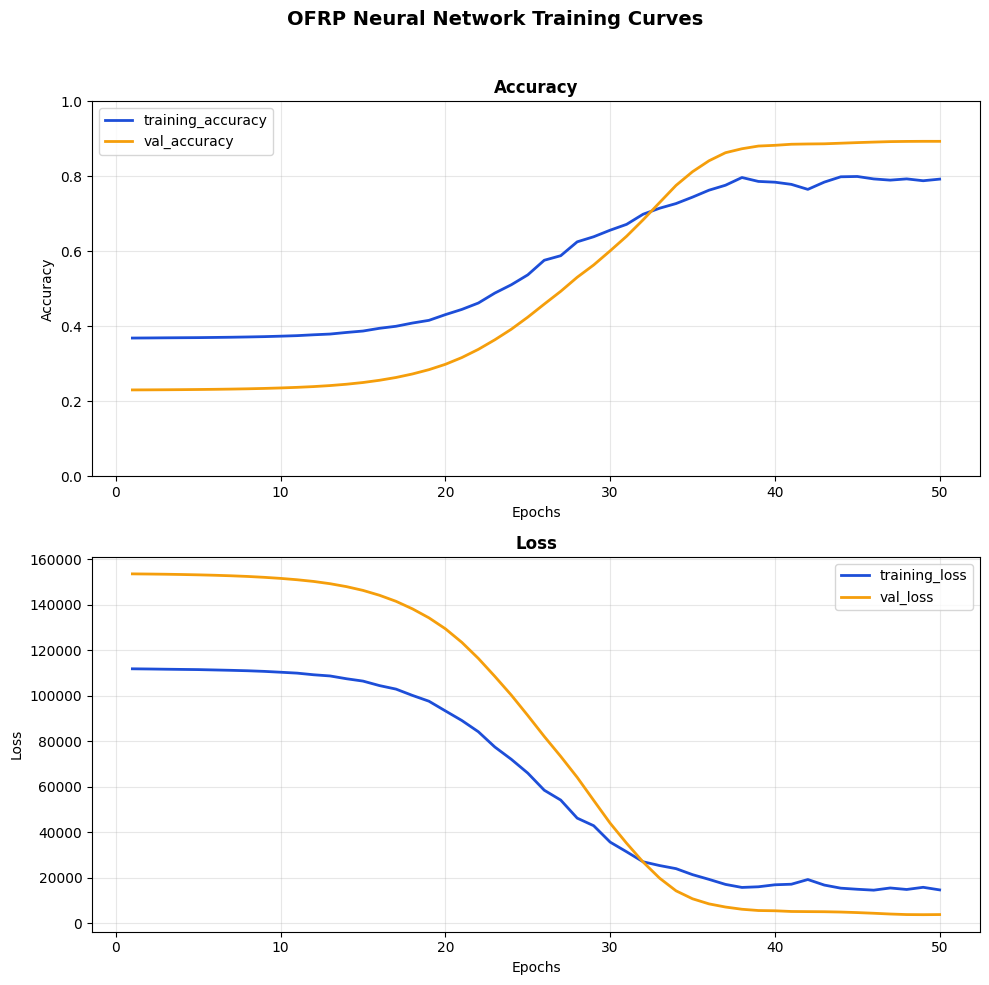


Saved Accuracy & Loss graphs to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\reports\figures\training_accuracy_loss.png


In [22]:
# ==============================
# NEURAL NETWORK EVALUATION & VISUALIZATION
# ==============================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

if history is None:
    print('Skipping graph generation: insufficient training data for neural network')
else:
    # Get predictions on test set
    y_pred_nn = nn_model.predict(X_test_scaled, verbose=0)
    y_pred_nn = y_pred_nn.flatten()

    # Calculate proper regression metrics
    nn_r2 = r2_score(y_test, y_pred_nn)
    nn_mae = mean_absolute_error(y_test, y_pred_nn)
    nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
    nn_mape = np.mean(np.abs((y_test - y_pred_nn) / np.maximum(np.abs(y_test), 1e-9))) * 100

    print('[Neural Network Evaluation]')
    print(f'  R² Score: {nn_r2:.4f}')
    print(f'  MAE: {nn_mae:.2f}')
    print(f'  RMSE: {nn_rmse:.2f}')
    print(f'  MAPE: {nn_mape:.2f}%')

    model_name = BOAT_TYPE_TARGET if 'BOAT_TYPE_TARGET' in globals() and BOAT_TYPE_TARGET else (
        TARGET if 'TARGET' in globals() else 'Neural Network'
    )

    # ==============================
    # PLOT 1: Accuracy
    # PLOT 2: Loss
    # ==============================

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    fig.suptitle(f'{model_name} Neural Network Training Curves', fontsize=14, fontweight='bold')

    epochs = range(1, len(history.history['loss']) + 1)
    y_train_max = max(float(np.max(np.asarray(y_train))), 1e-9)

    # --- SUBPLOT 1: Accuracy ---
    if 'mae' in history.history:
        train_accuracy = np.clip(1.0 - (np.array(history.history['mae']) / y_train_max), 0.0, 1.0)
        axes[0].plot(epochs, train_accuracy, label='training_accuracy', linewidth=2, color='#1d4ed8')

        if 'val_mae' in history.history:
            val_accuracy = np.clip(1.0 - (np.array(history.history['val_mae']) / y_train_max), 0.0, 1.0)
            axes[0].plot(epochs, val_accuracy, label='val_accuracy', linewidth=2, color='#f59e0b')
    else:
        train_accuracy = np.clip(1.0 - (np.array(history.history['loss']) / (np.max(np.array(history.history['loss'])) + 1e-9)), 0.0, 1.0)
        axes[0].plot(epochs, train_accuracy, label='training_accuracy', linewidth=2, color='#1d4ed8')

        if 'val_loss' in history.history:
            val_accuracy = np.clip(1.0 - (np.array(history.history['val_loss']) / (np.max(np.array(history.history['val_loss'])) + 1e-9)), 0.0, 1.0)
            axes[0].plot(epochs, val_accuracy, label='val_accuracy', linewidth=2, color='#f59e0b')

    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- SUBPLOT 2: Loss ---
    axes[1].plot(epochs, history.history['loss'], label='training_loss', linewidth=2, color='#1d4ed8')

    if 'val_loss' in history.history:
        axes[1].plot(epochs, history.history['val_loss'], label='val_loss', linewidth=2, color='#f59e0b')

    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save the figure
    nn_figure_path = figure_dir / 'training_accuracy_loss.png'
    fig.savefig(nn_figure_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'\nSaved Accuracy & Loss graphs to: {nn_figure_path}')

In [23]:
# ==============================
# SAVE NEURAL NETWORK MODEL
# ==============================

# Save the neural network model as pickle directly in best_model folder
nn_model_path = target_dir / f'{BOAT_TYPE_TARGET.lower()}_neural_network_model.pkl'
import pickle
with open(nn_model_path, 'wb') as f:
    pickle.dump(nn_model, f)

# Save model metrics
nn_metrics = {
    'model_type': 'neural_network',
    'boat_type': BOAT_TYPE_TARGET,
    'r2_score': float(nn_r2),
    'mae': float(nn_mae),
    'rmse': float(nn_rmse),
    'mape': float(nn_mape),
    'test_samples': int(len(y_test)),
    'epochs_trained': int(len(history.history['loss']))
}

nn_metrics_file = target_dir / 'neural_network_metrics.json'
nn_metrics_file.write_text(json.dumps(nn_metrics, indent=2), encoding='utf-8')

print(f'Saved neural network model to: {nn_model_path}')
print(f'Saved neural network metrics to: {nn_metrics_file}')

Saved neural network model to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\ofrp_neural_network_model.pkl
Saved neural network metrics to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\neural_network_metrics.json


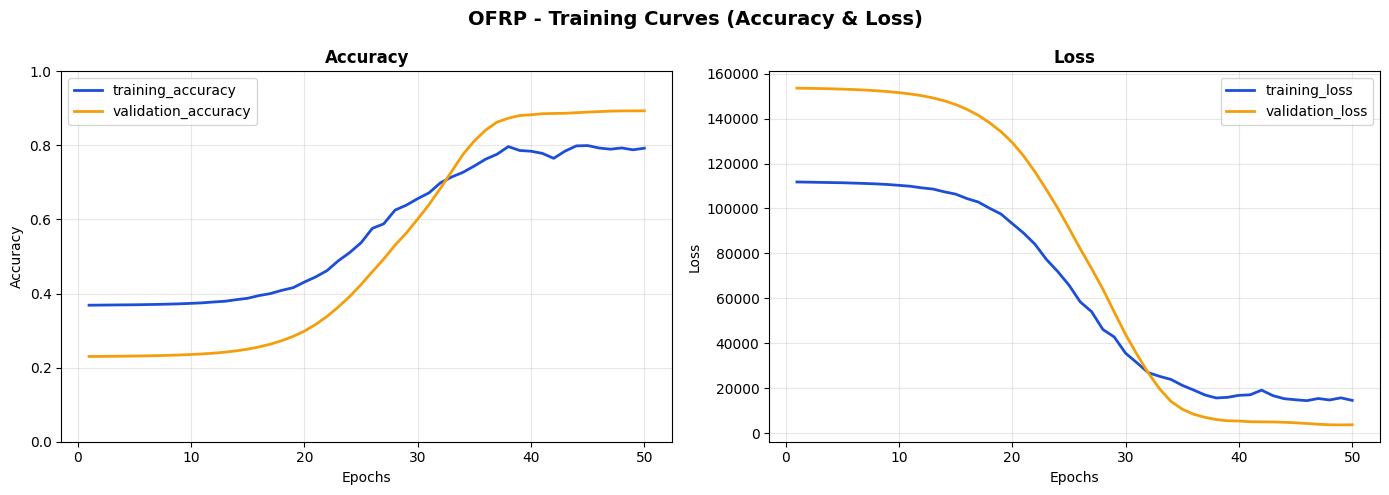

Saved simple accuracy & loss graphs to: c:\Users\Piuminda Jayaweera\Desktop\discD\New folder\fishai\final_year_research\model\cost_prediction\models\fishtripcost\boat_type\ofrp\best_model\reports\figures\training_accuracy_loss.png


In [24]:
# ==============================
# SIMPLE 2-PANEL: TRAINING CURVES (Quick Overview)
# ==============================

if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{BOAT_TYPE_TARGET} - Training Curves (Accuracy & Loss)', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history.history['loss']) + 1)
    y_train_max = y_train.max()
    
    # --- LEFT: Accuracy ---
    train_accuracy = 1.0 - (np.array(history.history['mae']) / y_train_max)
    train_accuracy = np.clip(train_accuracy, 0, 1)
    val_accuracy = 1.0 - (np.array(history.history['val_mae']) / y_train_max)
    val_accuracy = np.clip(val_accuracy, 0, 1)
    
    axes[0].plot(epochs, train_accuracy, label='training_accuracy', linewidth=2, color='#1d4ed8')
    axes[0].plot(epochs, val_accuracy, label='validation_accuracy', linewidth=2, color='#f59e0b')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # --- RIGHT: Loss ---
    axes[1].plot(epochs, history.history['loss'], label='training_loss', linewidth=2, color='#1d4ed8')
    axes[1].plot(epochs, history.history['val_loss'], label='validation_loss', linewidth=2, color='#f59e0b')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    simple_figure_path = figure_dir / 'training_accuracy_loss.png'
    fig.savefig(simple_figure_path, dpi=160, bbox_inches='tight')
    print(f'Saved simple accuracy & loss graphs to: {simple_figure_path}')